# Project: Resume Screening Automation
# Objective: Automate resume filtering to match candidates with job openings
# Data Science Internship - Internee.pk


In [2]:
import pandas as pd
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nlp = spacy.load("en_core_web_sm")

resumes = pd.read_csv("Resume.csv")
print("Resumes Loaded:", resumes.shape)
resumes.head()

Resumes Loaded: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
jobs = pd.read_csv("jobs.csv")
print("Job Descriptions Loaded:", jobs.shape)
jobs.head()

Job Descriptions Loaded: (5, 3)


,Job_ID,Title,Description
0,101,Data Science Intern,"Looking for candidates with Python, Machine Le..."
1,102,Software Developer Intern,"Looking for candidates with Java, Spring Boot,..."
2,103,Business Analyst Intern,"Looking for candidates with SQL, Excel, and Bu..."
3,104,Web Developer Intern,"Looking for candidates with JavaScript, React,..."
4,105,Machine Learning Intern,"Looking for candidates with Python, TensorFlow..."


In [4]:
resumes = resumes.rename(columns={
    "ID": "Candidate_ID",
    "Resume_str": "Resume_Text"
})

resumes = resumes[["Candidate_ID", "Resume_Text"]]
resumes.head()

,Candidate_ID,Resume_Text
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...
1,22323967,"HR SPECIALIST, US HR OPERATIONS ..."
2,33176873,HR DIRECTOR Summary Over 2...
3,27018550,HR SPECIALIST Summary Dedica...
4,17812897,HR MANAGER Skill Highlights ...


 Preprocessing Text Using spaCy

In [5]:
def extract_keywords(text):
    doc = nlp(str(text).lower())
    keywords = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
    return " ".join(keywords)

resumes['Cleaned_Resume'] = resumes['Resume_Text'].apply(extract_keywords)
jobs['Cleaned_Description'] = jobs['Description'].apply(extract_keywords)

resumes.head(), jobs.head()

(   Candidate_ID                                        Resume_Text  \
 0      16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
 1      22323967           HR SPECIALIST, US HR OPERATIONS      ...   
 2      33176873           HR DIRECTOR       Summary      Over 2...   
 3      27018550           HR SPECIALIST       Summary    Dedica...   
 4      17812897           HR MANAGER         Skill Highlights  ...   
 
                                       Cleaned_Resume  
 0  hr administrator marketing associate hr admini...  
 1  hr specialist hr operation summary versatile m...  
 2  hr director summary year experience recruiting...  
 3  hr specialist summary dedicate driven dynamic ...  
 4  hr manager skill highlight hr skill hr departm...  ,
    Job_ID                      Title  \
 0     101        Data Science Intern   
 1     102  Software Developer Intern   
 2     103    Business Analyst Intern   
 3     104       Web Developer Intern   
 4     105    Machine Learning

TF-IDF Vectorization

In [6]:
all_texts = pd.concat([resumes['Cleaned_Resume'], jobs['Cleaned_Description']])

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(all_texts)

resume_vectors = tfidf_matrix[:len(resumes)]
job_vectors = tfidf_matrix[len(resumes):]

Computing Cosine Similarity

In [7]:
similarity_matrix = cosine_similarity(resume_vectors, job_vectors)
similarity_matrix

array([[0.00368383, 0.00176215, 0.01352146, 0.0022469 , 0.00186943],
       [0.01081631, 0.000872  , 0.00937436, 0.00111188, 0.00092508],
       [0.00138902, 0.00132887, 0.00763683, 0.00169442, 0.00140977],
       ...,
       [0.00161063, 0.00308176, 0.00236068, 0.00392952, 0.00326937],
       [0.00070518, 0.00202394, 0.01033466, 0.00258071, 0.00214716],
       [0.01214042, 0.00156249, 0.01795889, 0.00199232, 0.00165761]])

Ranking Candidates for Each Job

In [9]:
results = []

for job_index, job in jobs.iterrows():
    sim_scores = similarity_matrix[:, job_index]

    ranked_candidates = resumes[["Candidate_ID"]].copy()
    ranked_candidates["Similarity_Score"] = sim_scores
    ranked_candidates = ranked_candidates.sort_values(
        by="Similarity_Score",
        ascending=False
    )

    results.append({
        "Job_ID": job["Job_ID"],
        "Job_Title": job["Title"],
        "Top_Candidates": ranked_candidates.head(5)
    })

results

[{'Job_ID': 101,
  'Job_Title': 'Data Science Intern',
  'Top_Candidates':       Candidate_ID  Similarity_Score
  53        13520837          0.175311
  91        18297650          0.146391
  746       26958533          0.125160
  723       17864043          0.118784
  2153      34953092          0.097122},
 {'Job_ID': 102,
  'Job_Title': 'Software Developer Intern',
  'Top_Candidates':       Candidate_ID  Similarity_Score
  297       83816738          0.245156
  91        18297650          0.163188
  53        13520837          0.160389
  2163      22615491          0.139875
  124       85101052          0.138345},
 {'Job_ID': 103,
  'Job_Title': 'Business Analyst Intern',
  'Top_Candidates':       Candidate_ID  Similarity_Score
  1142      30863060          0.281473
  53        13520837          0.263262
  243       13385306          0.261264
  229       36434348          0.240003
  91        18297650          0.237734},
 {'Job_ID': 104,
  'Job_Title': 'Web Developer Intern',
  'Top_

Displaying Ranked Candidates in Table

In [11]:
for job in results:
    print("\n==============================")
    print("Job:", job["Job_Title"])
    print("==============================")
    print(job["Top_Candidates"])


Job: Data Science Intern
      Candidate_ID  Similarity_Score
53        13520837          0.175311
91        18297650          0.146391
746       26958533          0.125160
723       17864043          0.118784
2153      34953092          0.097122

Job: Software Developer Intern
      Candidate_ID  Similarity_Score
297       83816738          0.245156
91        18297650          0.163188
53        13520837          0.160389
2163      22615491          0.139875
124       85101052          0.138345

Job: Business Analyst Intern
      Candidate_ID  Similarity_Score
1142      30863060          0.281473
53        13520837          0.263262
243       13385306          0.261264
229       36434348          0.240003
91        18297650          0.237734

Job: Web Developer Intern
      Candidate_ID  Similarity_Score
53        13520837          0.204510
91        18297650          0.171601
1742      51588273          0.141448
723       17864043          0.139555
71        14640322          0.1128

Visualizing Top Candidates per Job

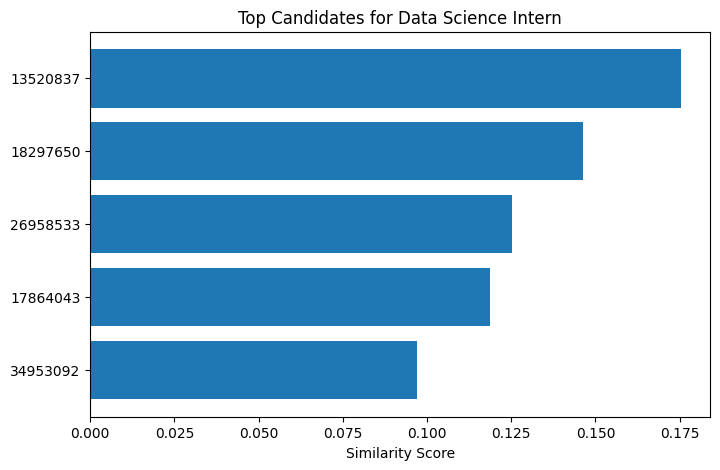

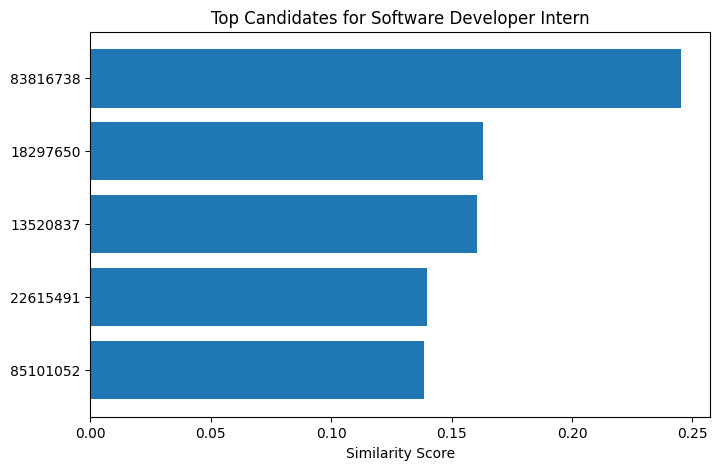

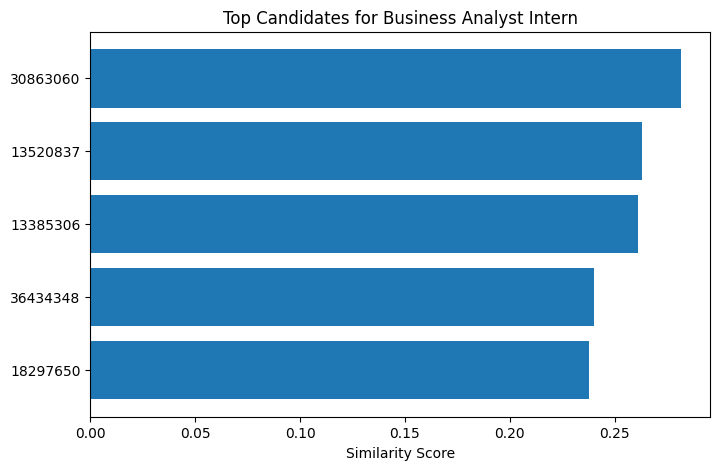

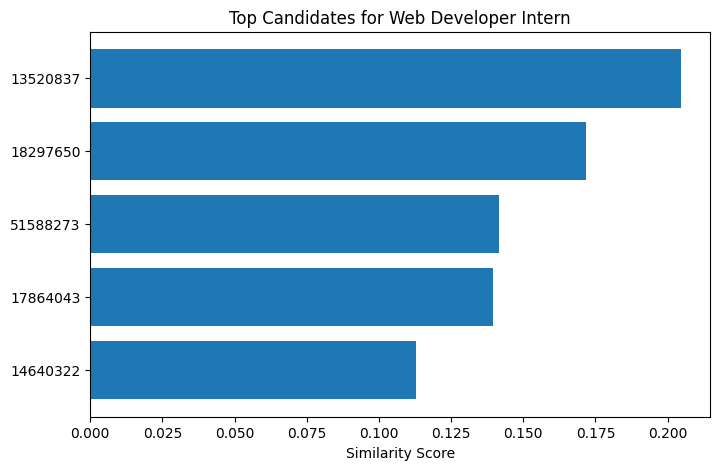

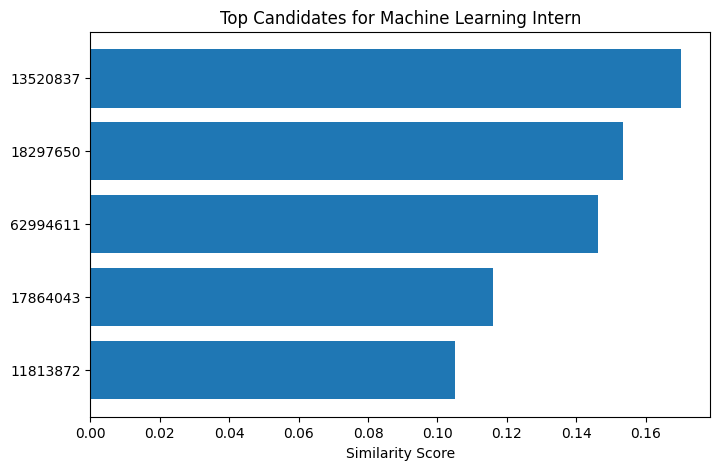

In [13]:
import matplotlib.pyplot as plt

for job in results:
    df = job["Top_Candidates"]

    names = df["Candidate_ID"].astype(str)
    scores = df["Similarity_Score"]

    plt.figure(figsize=(8,5))
    plt.barh(names, scores)
    plt.xlabel("Similarity Score")
    plt.title(f"Top Candidates for {job['Job_Title']}")
    plt.gca().invert_yaxis()
    plt.show()

 Save Ranked Results to CSV

In [14]:
final_rows = []

for job in results:
    for _, row in job["Top_Candidates"].iterrows():
        final_rows.append({
            "Job_ID": job["Job_ID"],
            "Job_Title": job["Job_Title"],
            "Candidate_ID": row["Candidate_ID"],
            "Similarity_Score": row["Similarity_Score"]
        })

final_df = pd.DataFrame(final_rows)
final_df.to_csv("ranked_candidates.csv", index=False)

print("Saved as ranked_candidates.csv")
final_df.head()

Saved as ranked_candidates.csv


,Job_ID,Job_Title,Candidate_ID,Similarity_Score
0,101,Data Science Intern,13520837.0,0.175311
1,101,Data Science Intern,18297650.0,0.146391
2,101,Data Science Intern,26958533.0,0.125160
3,101,Data Science Intern,17864043.0,0.118784
4,101,Data Science Intern,34953092.0,0.097122
